In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('titanic task5.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

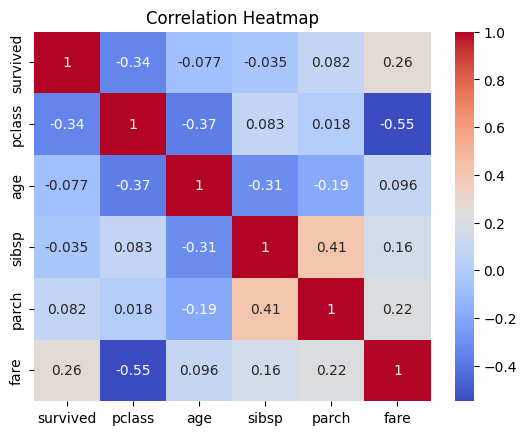

In [8]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Fare aur survived ke beech positive correlation hai. Pclass aur survived ke beech negative correlation hai.

sns.pairplot(df[['age','fare','pclass','survived']].dropna(), hue='survived')
plt.show()

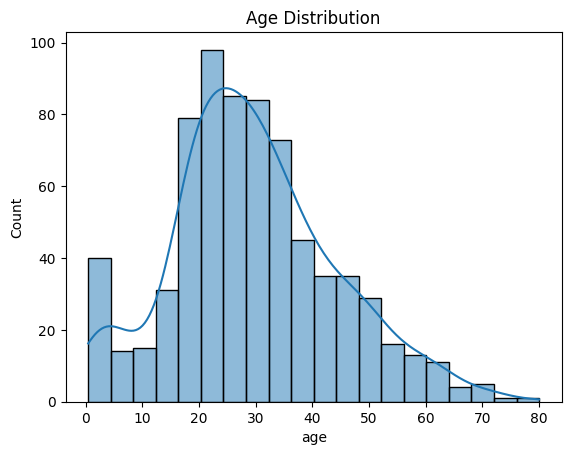

In [10]:
sns.histplot(df['age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()

Age distribution roughly normal hai, 20-30 age group me sabse zyada passengers hain.

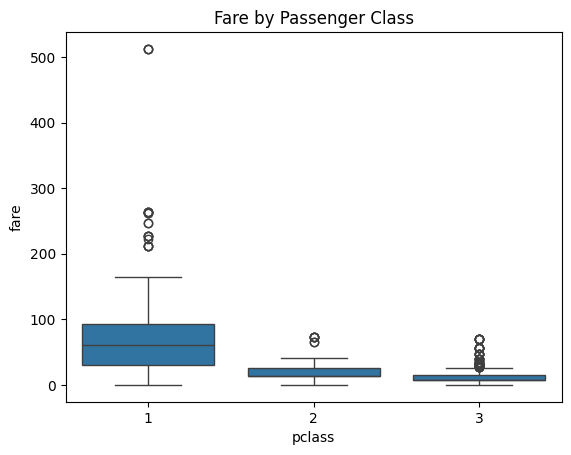

In [11]:
sns.boxplot(x='pclass', y='fare', data=df)
plt.title('Fare by Passenger Class')
plt.show()

Observation: 1st class passengers ka fare sabse zyada aur variable hai, jisme ek extreme outlier bhi hai (~512). 2nd aur 3rd class ka fare kaafi kam aur consistent hai. Isse pata chalta hai ki fare directly passenger class se juda hua hai.

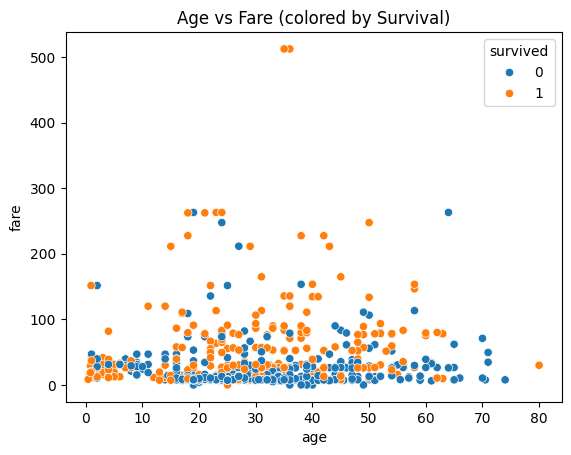

In [12]:
sns.scatterplot(x='age', y='fare', hue='survived', data=df)
plt.title('Age vs Fare (colored by Survival)')
plt.show()

Observation: Age distribution roughly normal hai, 20-30 age group me sabse zyada passengers hain.

Summary of Findings:

1. Age column me 177 missing values the, jo dataset ka ~20% hai. Deck column me sabse zyada missing values (688) the.

2. Fare distribution heavily right-skewed hai - zyadatar tickets sasti hain lekin kuch outliers (500+) bhi hain.

3. Fare aur survived ke beech positive correlation hai (0.26) - jyada fare wale passengers ki survival chance zyada thi.

4. Pclass aur survived ke beech negative correlation hai (-0.34) - 3rd class passengers ki survival rate sabse kam thi, jabki 1st class passengers zyada survive hue.

5. 1st class ka fare sabse zyada aur variable tha, 3rd class ka fare sabse kam aur consistent tha.

6. Age akela survival ka strong predictor nahi hai, lekin fare ke saath combine hone par pattern dikhta hai - high fare wale passengers me survival rate zyada thi.

7. Overall, Titanic dataset me passenger class aur fare, survival ke sabse strong indicators nikle, age ka utna direct effect nahi tha.